In [1]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

In [2]:
image_path = "konak.jpg"

In [3]:
img = Image.open(image_path).convert("L")
img = np.array(img)
print(img.shape)

(416, 625)


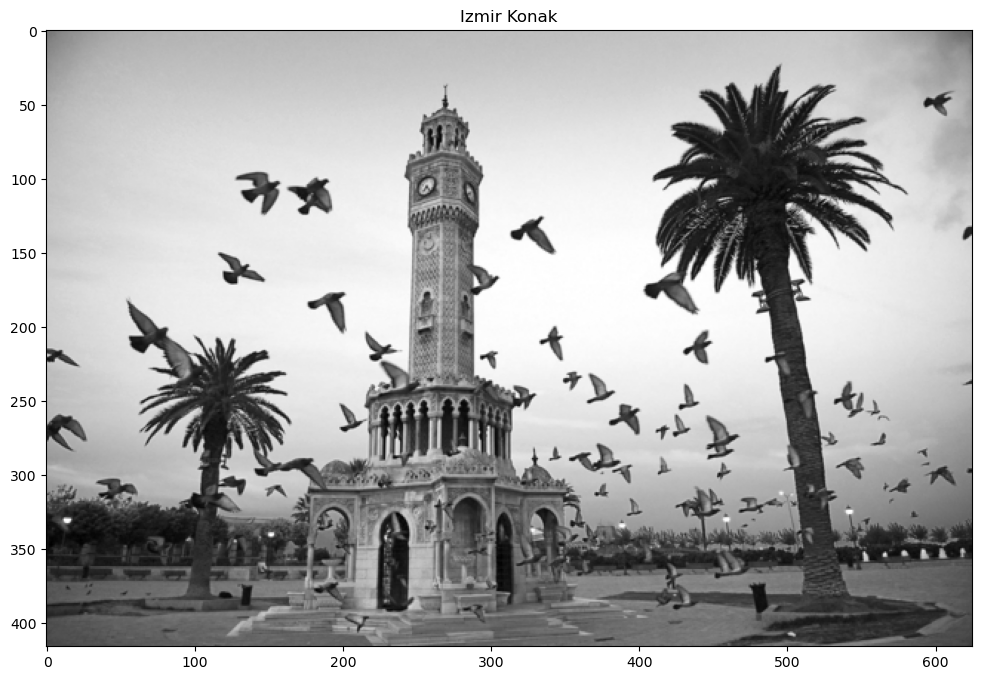

In [4]:
plt.figure(figsize=(12, 8))
plt.title("Izmir Konak")
plt.imshow(img, cmap="gray")
plt.show()

In [5]:
filter_0 = np.array([
    [1, 0, -1],
    [1, 0, -1],
    [1, 0, -1]
])

In [6]:
def apply_filter(img, filter):
    img_height, img_width = img.shape
    print(f"Image height: {img_height}, width: {img_width}")

    filter_height, filter_width = filter.shape
    print(f"Filter height: {filter_height}, width: {filter_width}")

    num_horizontal_movements = img_width - filter_width + 1
    num_vertical_movements = img_height - filter_height + 1

    filtered_img = np.zeros((num_vertical_movements, num_horizontal_movements))

    for i in range(num_vertical_movements):
        for j in range(num_horizontal_movements):
            img_subset = img[i: i+filter_height, j: j+filter_width]
            summation = np.sum(img_subset * filter)
            filtered_img[i, j] = summation

    return filtered_img

Image height: 416, width: 625
Filter height: 3, width: 3
min - max: -642.0 667.0


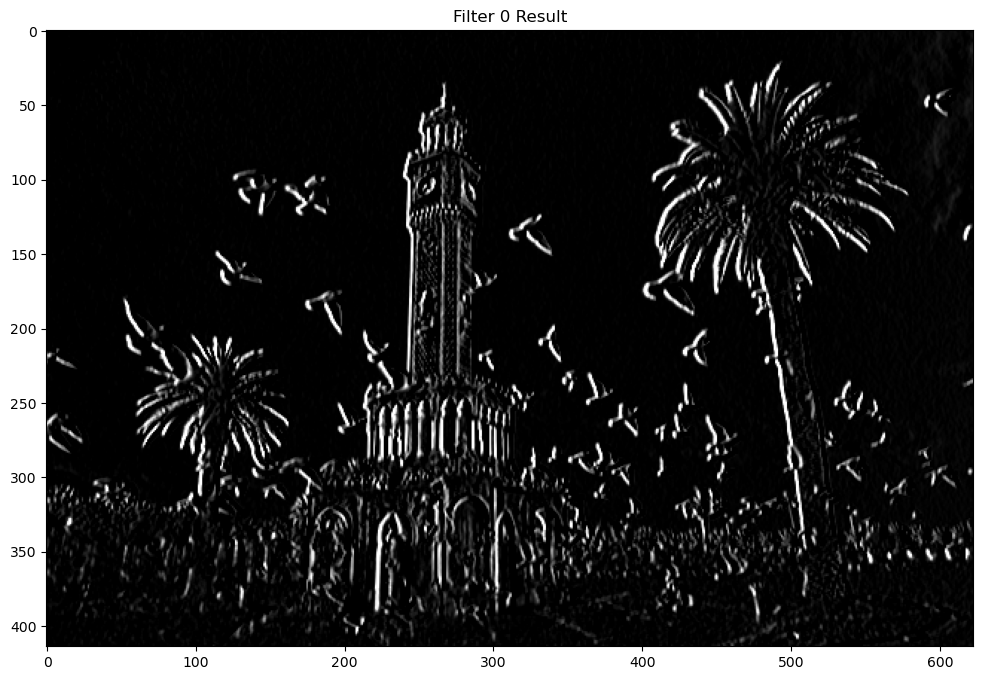

In [7]:
filtered_img_0 = apply_filter(img, filter_0)
print("min - max:", filtered_img_0.min(), filtered_img_0.max())
filtered_img_0 = np.clip(filtered_img_0, 0, 255)
plt.figure(figsize=(12, 8))
plt.title("Filter 0 Result")
plt.imshow(filtered_img_0, cmap="gray")
plt.show()

Image height: 416, width: 625
Filter height: 3, width: 3


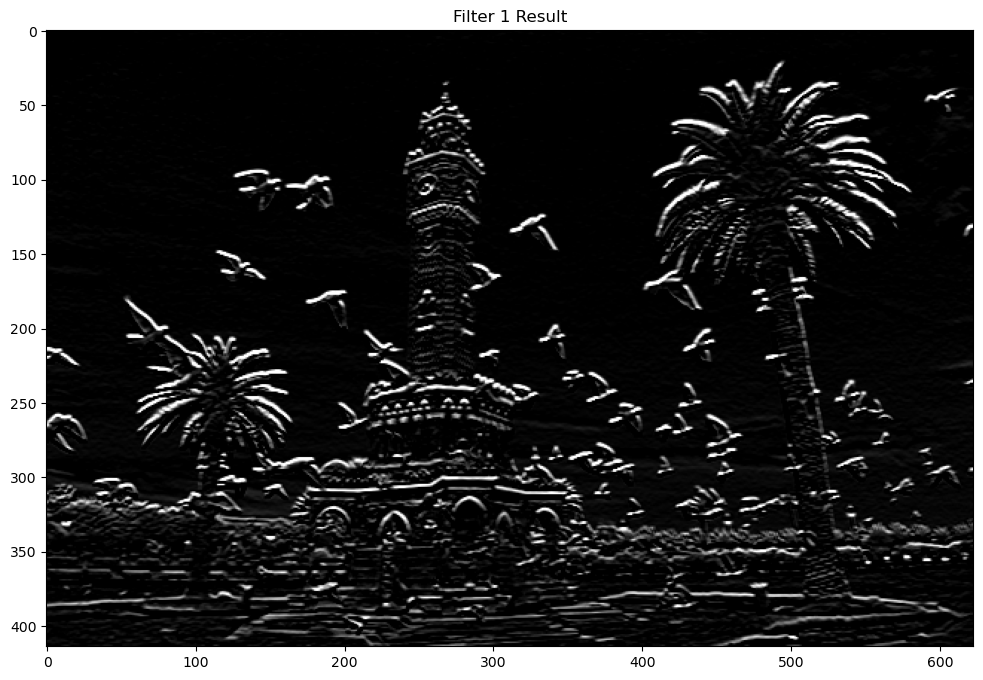

In [8]:
filter_1 = np.array([
    [1, 1, 1],
    [0, 0, 0],
    [-1, -1, -1]
])
filtered_img_1 = apply_filter(img, filter_1)
filtered_img_1 = np.clip(filtered_img_1, 0, 255)
plt.figure(figsize=(12, 8))
plt.title("Filter 1 Result")
plt.imshow(filtered_img_1, cmap="gray")
plt.show()

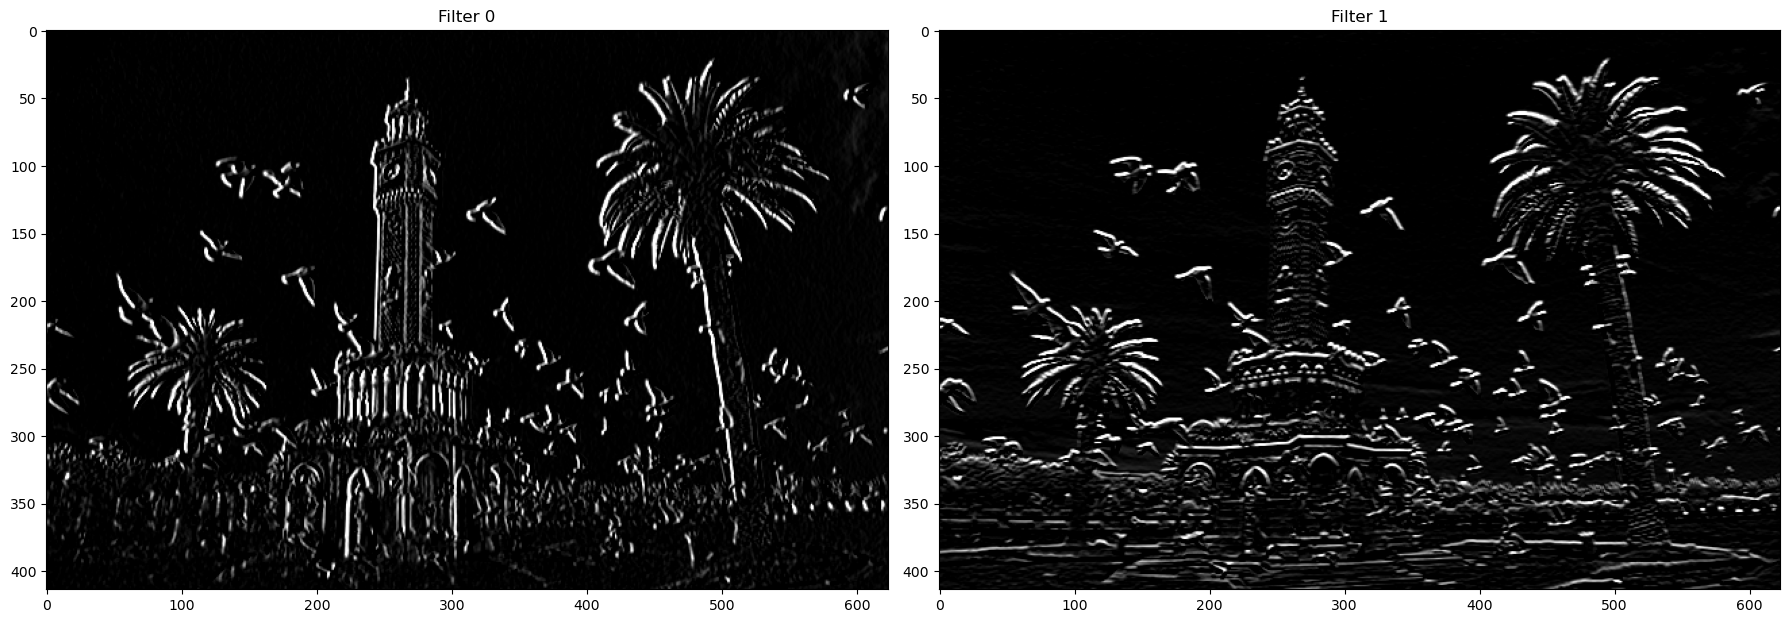

In [9]:
plt.figure(figsize=(18, 9))
plt.subplot(1, 2, 1)
plt.title("Filter 0")
plt.imshow(filtered_img_0, cmap="gray")
plt.subplot(1, 2, 2)
plt.title("Filter 1")
plt.imshow(filtered_img_1, cmap="gray")
plt.tight_layout()
plt.show()

Image height: 416, width: 625
Filter height: 3, width: 3
Image height: 416, width: 625
Filter height: 3, width: 3


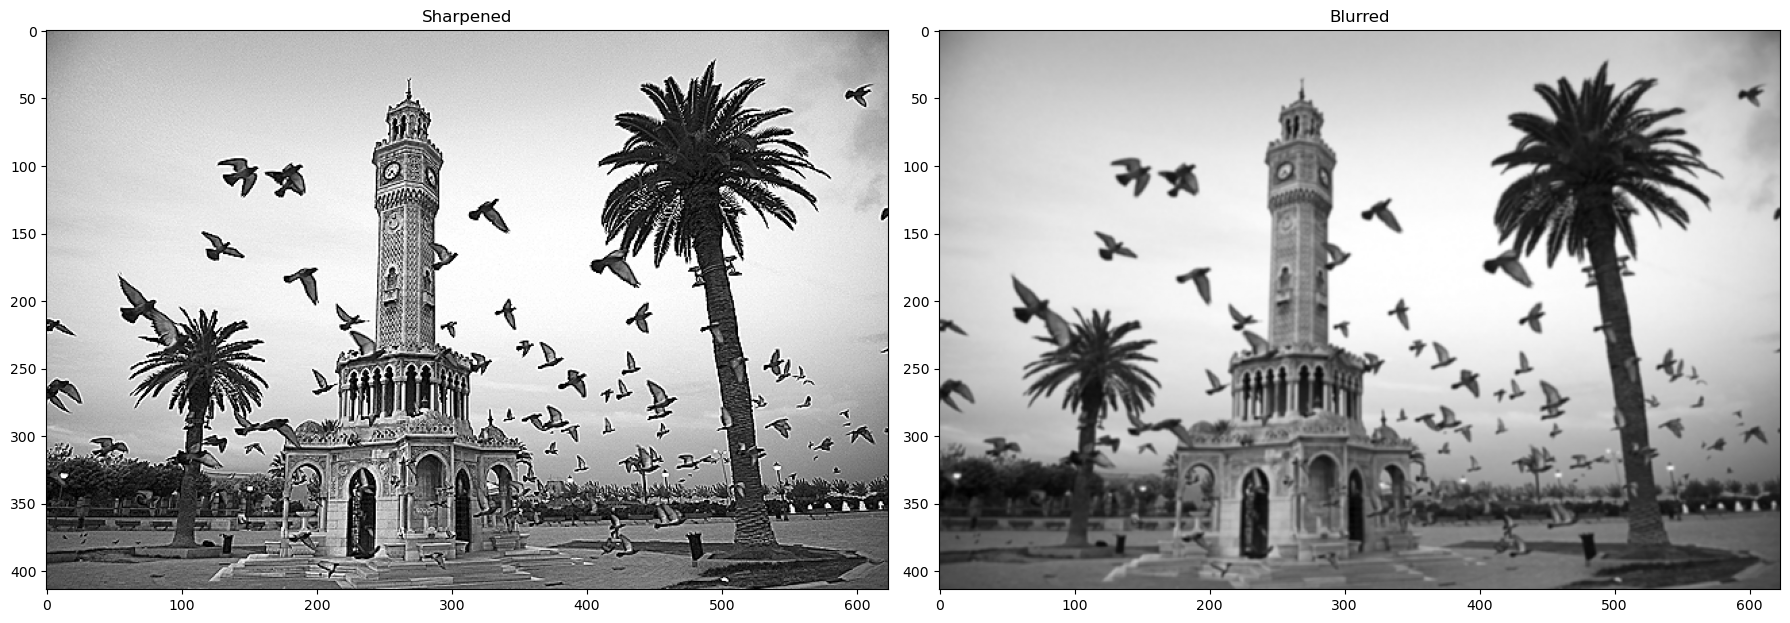

In [10]:
sharpen = np.array([[0, -1, 0],
                    [-1, 5, -1],
                    [0, -1, 0]])
sharpened_img = apply_filter(img, sharpen)
sharpened_img = np.clip(sharpened_img, 0, 255)

gaussian = (1 / 16.0) * np.array([[1., 2., 1.],
                                  [2., 4., 2.],
                                  [1., 2., 1.]])
blurred_img = apply_filter(img, gaussian)
blurred_img = np.clip(blurred_img, 0, 255)

plt.figure(figsize=(18, 9))
plt.subplot(1, 2, 1)
plt.title("Sharpened")
plt.imshow(sharpened_img, cmap="gray")
plt.subplot(1, 2, 2)
plt.title("Blurred")
plt.imshow(blurred_img, cmap="gray")
plt.tight_layout()
plt.show()

### Stride

In [11]:
def convolve_with_stride(img, filter, stride=1):
    img_height, img_width = img.shape
    print(f"Image height: {img_height}, width: {img_width}")

    filter_height, filter_width = filter.shape
    print(f"Filter height: {filter_height}, width: {filter_width}")

    target_img_height = math.floor((img_height - filter_height) / stride) + 1
    target_img_width = math.floor((img_width - filter_width) / stride) + 1
    print(
        f"Target image height: {target_img_height}, width: {target_img_width}")

    filtered_img = np.zeros((target_img_height, target_img_width))

    for i in range(target_img_height):
        for j in range(target_img_width):
            img_subset = img[i*stride: i*stride + filter_height,
                             j*stride: j*stride+filter_width]
            summation = np.sum(img_subset * filter)
            filtered_img[i, j] = summation

    return filtered_img

In [12]:
filter_4 = np.array([
    [0, -1, 0],
    [-1, 0, 1],
    [0, 1, 0]
])

filtered_img_4 = convolve_with_stride(img, filter_4, stride=1)
filtered_img_4 = np.clip(filtered_img_4, 0, 255)

filtered_img_5 = convolve_with_stride(img, filter_4, stride=2)
filtered_img_5 = np.clip(filtered_img_5, 0, 255)

plt.figure(figsize=(18, 9))
plt.subplot(1, 2, 1)
plt.title("Stride = 1")
plt.imshow(filtered_img_4, cmap="gray")
plt.subplot(1, 2, 2)
plt.title("Stride = 2")
plt.imshow(filtered_img_5, cmap="gray")
plt.tight_layout()
plt.show()

Image height: 416, width: 625
Filter height: 3, width: 3


NameError: name 'math' is not defined

### Max Pooling

In [ ]:
def max_pool(img, pool_size=4, stride=2):
    img_height, img_width = img.shape
    print(f"Image height: {img_height}, width: {img_width}")

    target_img_height = math.floor((img_height - pool_size) / stride) + 1
    target_img_width = math.floor((img_width - pool_size) / stride) + 1
    print(
        f"Target image height: {target_img_height}, width: {target_img_width}")

    pooled_img = np.zeros((target_img_height, target_img_width))

    for i in range(target_img_height):
        for j in range(target_img_width):
            img_subset = img[i*stride: i*stride +
                             pool_size, j*stride: j*stride+pool_size]
            pooled_img[i, j] = np.max(img_subset)

    return pooled_img

In [ ]:
max_pooled_img = max_pool(img, pool_size=4, stride=4)

plt.figure(figsize=(18, 9))
plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(img, cmap="gray")
plt.subplot(1, 2, 2)
plt.title("Max Pooled Image")
plt.imshow(max_pooled_img, cmap="gray")
plt.tight_layout()
plt.show()

In [ ]:
def avg_pool(img, pool_size=4, stride=2):
    img_height, img_width = img.shape
    print(f"Image height: {img_height}, width: {img_width}")

    target_img_height = math.floor((img_height - pool_size) / stride) + 1
    target_img_width = math.floor((img_width - pool_size) / stride) + 1
    print(
        f"Target image height: {target_img_height}, width: {target_img_width}")

    pooled_img = np.zeros((target_img_height, target_img_width))

    for i in range(target_img_height):
        for j in range(target_img_width):
            img_subset = img[i*stride: i*stride +
                             pool_size, j*stride: j*stride+pool_size]
            pooled_img[i, j] = np.average(img_subset)

    return pooled_img

In [ ]:
avg_pooled_img = avg_pool(img, pool_size=4, stride=4)

plt.figure(figsize=(18, 9))
plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(img, cmap="gray")
plt.subplot(1, 2, 2)
plt.title("Average Pooled Image")
plt.imshow(avg_pooled_img, cmap="gray")
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(18, 9))
plt.subplot(1, 2, 1)
plt.title("Average Pooled Image")
plt.imshow(avg_pooled_img, cmap="gray")
plt.subplot(1, 2, 2)
plt.title("Max Pooled Image")
plt.imshow(max_pooled_img, cmap="gray")
plt.tight_layout()
plt.show()